# Exploratory analysis / diagnostics

In [30]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [ ]:
# read in data
reviews = gpd.read_file("data/neigh_reviews_subset.gpkg")
# drop existing neighborhood-level gentrification indicators
reviews = reviews.drop(columns="gentrified")
reviews.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,index_right,LISTNAME,review_id,user_id,useful,funny,cool,text,date,geometry
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,BXQcBN0iAi1lAUxibGLFzA,6_SpY41LIHZuIaiDs5FMKA,0.0,0.0,1.0,This is nice little Chinese bakery in the hear...,2014-05-26 01:09:53,POINT (-75.15556 39.95551)
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,uduvUCvi9w3T2bSGivCfXg,tCXElwhzekJEH6QJe3xs7Q,3.0,1.0,2.0,This is the bakery I usually go to in Chinatow...,2013-10-05 15:19:06,POINT (-75.15556 39.95551)
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,a0vwPOqDXXZuJkbBW2356g,WqfKtI-aGMmvbA9pPUxNQQ,0.0,0.0,0.0,"A delightful find in Chinatown! Very clean, an...",2013-10-25 01:34:57,POINT (-75.15556 39.95551)
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,MKNp_CdR2k2202-c8GN5Dw,3-1va0IQfK-9tUMzfHWfTA,5.0,0.0,5.0,I ordered a graduation cake for my niece and i...,2018-05-20 17:58:57,POINT (-75.15556 39.95551)
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,D1GisLDPe84Rrk_R4X2brQ,EouCKoDfzaVG0klEgdDvCQ,2.0,1.0,1.0,HK-STYLE MILK TEA: FOUR STARS\n\nNot quite su...,2013-10-25 02:31:35,POINT (-75.15556 39.95551)


In [47]:
# check the columns
reviews.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'index_right', 'LISTNAME',
       'review_id', 'user_id', 'useful', 'funny', 'cool', 'text', 'date',
       'geometry'],
      dtype='object')

## Subset to brewery reviews

In [ ]:
# turn the strings in 'categories' to lowercase to make things easier
reviews['categories'] = reviews['categories'].str.lower()

# check out the unique values of reviews containing "brew"
reviews[reviews['categories'].str.contains("brew")]['categories'].unique()

array(['eatertainment, arts & entertainment, brewpubs, american (traditional), bakeries, breweries, food, restaurants',
       'nightlife, music venues, irish, pubs, irish pub, arts & entertainment, food, restaurants, breweries, bars, beer, wine & spirits',
       'food, restaurants, breweries, bars, nightlife',
       'breweries, brewpubs, food, hot dogs, restaurants, sandwiches',
       'american (new), bars, food, pubs, breweries, pizza, restaurants, nightlife',
       'food, breweries, restaurants',
       'brewpubs, food, restaurants, american (traditional), breweries',
       'american (traditional), nightlife, food, bars, restaurants, beer, wine & spirits, american (new), pubs, local flavor, breweries, event planning & services, venues & event spaces',
       'american (new), breweries, desserts, american (traditional), restaurants, food',
       'nightlife, breweries, bars, food, pubs, restaurants, brewpubs',
       'italian, brazilian, coffee & tea, breakfast & brunch, breweri

In [ ]:
# check out the unique values of reviews containing "beer" --  particularly to see if non-brewery establishments contain "beer"
reviews[reviews['categories'].str.contains("beer")]['categories'].unique()

array(['nightlife, bars, beer, wine & spirits, pubs, irish, food, restaurants',
       'food, nightlife, restaurants, irish pub, bars, irish, pubs, beer, wine & spirits, event planning & services, gastropubs, caterers',
       'bars, food, restaurants, beer, wine & spirits, american (traditional), nightlife',
       'chicken wings, nightlife, bars, delis, food, beer gardens, sandwiches, beer bar, restaurants, beer, wine & spirits, gastropubs',
       'beer, wine & spirits, restaurants, specialty food, food, sandwiches, delis, fruits & veggies, grocery',
       'food, restaurants, nightlife, pizza, bars, beer, wine & spirits',
       'italian, food, nightlife, pizza, bars, cocktail bars, beer, wine & spirits, restaurants',
       'nightlife, music venues, irish, pubs, irish pub, arts & entertainment, food, restaurants, breweries, bars, beer, wine & spirits',
       'food, delis, beer, wine & spirits, restaurants',
       'restaurants, burgers, nightlife, beer, wine & spirits, american (

In [ ]:
print(sum(reviews['categories'].str.contains("brewpubs")))
print(sum(reviews['categories'].str.contains("breweries")))
#print(sum(reviews['categories'].str.contains("beer"))) # we find including "beer" to be too general
print(sum(reviews['categories'].str.contains("beer bar")))

2160
7729
16137


In [32]:
brew_reviews = reviews[(reviews['categories'].str.contains("brewpubs")) | (reviews['categories'].str.contains("breweries")) | (reviews['categories'].str.contains("beer bar"))]

brew_reviews.shape[0]

22933

In [33]:
brew_reviews.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,LISTNAME,gentrified,review_id,user_id,useful,funny,cool,text,date,geometry
655,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,Philadelphia,PA,19123,39.962582,-75.135657,3.5,65,...,Northern Liberties,0.0,sQMYwwfj5tggxisUZXwgkA,KGEdaKlPI-Sv2K_pa2HKgg,0.0,0.0,0.0,This is a great place to take guests visiting ...,2019-07-22 22:48:30,POINT (-75.13566 39.96258)
656,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,Philadelphia,PA,19123,39.962582,-75.135657,3.5,65,...,Northern Liberties,0.0,c09IhAED9khTlK1Nw4Wf9A,kauJmG3ZiA-m5u0nPrjb4g,2.0,0.0,1.0,"As a bar, this place has almost everything you...",2019-06-25 15:55:26,POINT (-75.13566 39.96258)
657,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,Philadelphia,PA,19123,39.962582,-75.135657,3.5,65,...,Northern Liberties,0.0,1FIFzSnwuyGw0V0a75-1Nw,i8FUZZFocxs24W9FYrGRDQ,0.0,0.0,0.0,First time here and it is great! Huge open spa...,2019-03-29 23:11:14,POINT (-75.13566 39.96258)
658,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,Philadelphia,PA,19123,39.962582,-75.135657,3.5,65,...,Northern Liberties,0.0,5-YovLQWy6Srq0UnTdVhuw,BqJWbbmEiefT9c4u9Nj8BQ,0.0,0.0,0.0,Awesome place for families with kids under 8. ...,2019-04-13 18:44:14,POINT (-75.13566 39.96258)
659,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,Philadelphia,PA,19123,39.962582,-75.135657,3.5,65,...,Northern Liberties,0.0,M-38wpRyPVRT35MgRmLCjQ,Ddd0ZKIFQd_NYqclMXYFKw,0.0,0.0,0.0,"The BEST new addition, especially for families...",2019-05-13 01:56:25,POINT (-75.13566 39.96258)


## Join with census tract gentrification indicators

In [ ]:
tracts_gent = gpd.read_file("data/Philadelphia_Tracts_Gent.geojson")
tracts_gent.head() 

In [53]:
tracts_gent.columns

Index(['FID', 'OBJECTID', 'STATEFP10', 'COUNTYFP10', 'TRACTCE10', 'GEOID10',
       'NAME10', 'NAMELSAD10', 'MTFCC10', 'FUNCSTAT10', 'ALAND10', 'AWATER10',
       'INTPTLAT10', 'INTPTLON10', 'LOGRECNO', 'SHAPE_AREA', 'SHAPE_LEN',
       'GentYN', 'geometry'],
      dtype='object')

In [ ]:
#brew_reviews = brew_reviews.drop(columns="index_right")
brew_reviews.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'LISTNAME', 'gentrified',
       'review_id', 'user_id', 'useful', 'funny', 'cool', 'text', 'date',
       'geometry'],
      dtype='object')

In [57]:
# spatial join with reviews data
reviews_tracts = brew_reviews.sjoin(tracts_gent[["GentYN", "TRACTCE10", "GEOID10", "geometry"]], how = "left",predicate= "intersects")
reviews_tracts.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,useful,funny,cool,text,date,geometry,index_right,GentYN,TRACTCE10,GEOID10
655,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,Philadelphia,PA,19123,39.962582,-75.135657,3.5,65,...,0.0,0.0,0.0,This is a great place to take guests visiting ...,2019-07-22 22:48:30,POINT (-75.13566 39.96258),179.0,0.0,014200,42101014200
656,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,Philadelphia,PA,19123,39.962582,-75.135657,3.5,65,...,2.0,0.0,1.0,"As a bar, this place has almost everything you...",2019-06-25 15:55:26,POINT (-75.13566 39.96258),179.0,0.0,014200,42101014200
657,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,Philadelphia,PA,19123,39.962582,-75.135657,3.5,65,...,0.0,0.0,0.0,First time here and it is great! Huge open spa...,2019-03-29 23:11:14,POINT (-75.13566 39.96258),179.0,0.0,014200,42101014200
658,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,Philadelphia,PA,19123,39.962582,-75.135657,3.5,65,...,0.0,0.0,0.0,Awesome place for families with kids under 8. ...,2019-04-13 18:44:14,POINT (-75.13566 39.96258),179.0,0.0,014200,42101014200
659,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,Philadelphia,PA,19123,39.962582,-75.135657,3.5,65,...,0.0,0.0,0.0,"The BEST new addition, especially for families...",2019-05-13 01:56:25,POINT (-75.13566 39.96258),179.0,0.0,014200,42101014200


## Time series plots

In [59]:
print(min(brew_reviews.date))
print(max(brew_reviews.date))

2005-10-03 02:48:13
2022-01-19 19:03:21


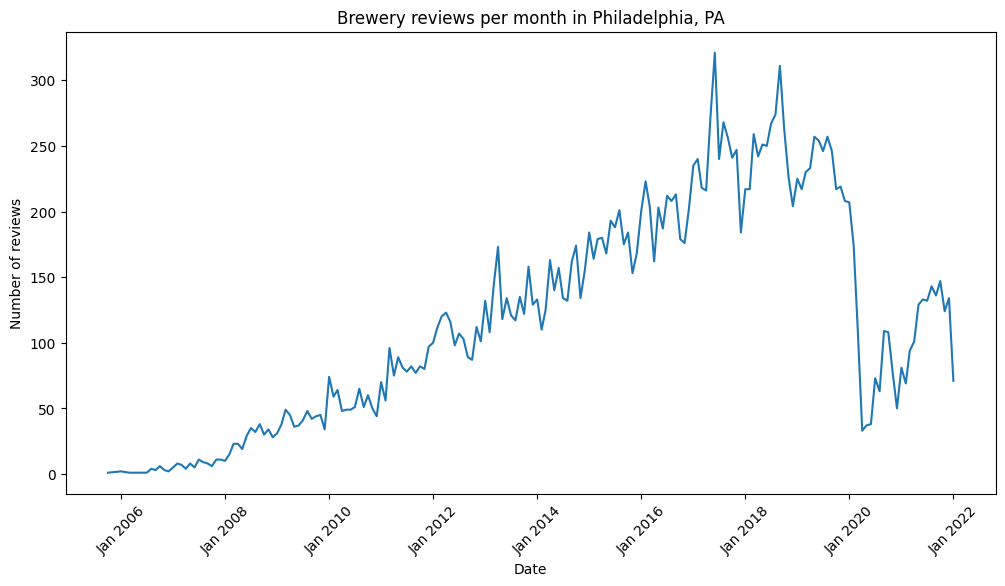

In [63]:
# plot number of brewery reviews across time

reviews_tracts['date'] = pd.to_datetime(reviews_tracts['date'])

review_counts = reviews_tracts.groupby(reviews_tracts['date'].dt.to_period('M')).size().reset_index(name='n')
review_counts['date'] = review_counts['date'].dt.to_timestamp()
review_counts.set_index("date", inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(review_counts['n'])
plt.xlabel("Date")
plt.ylabel("Number of reviews")
plt.title("Brewery reviews per month in Philadelphia, PA")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.show()

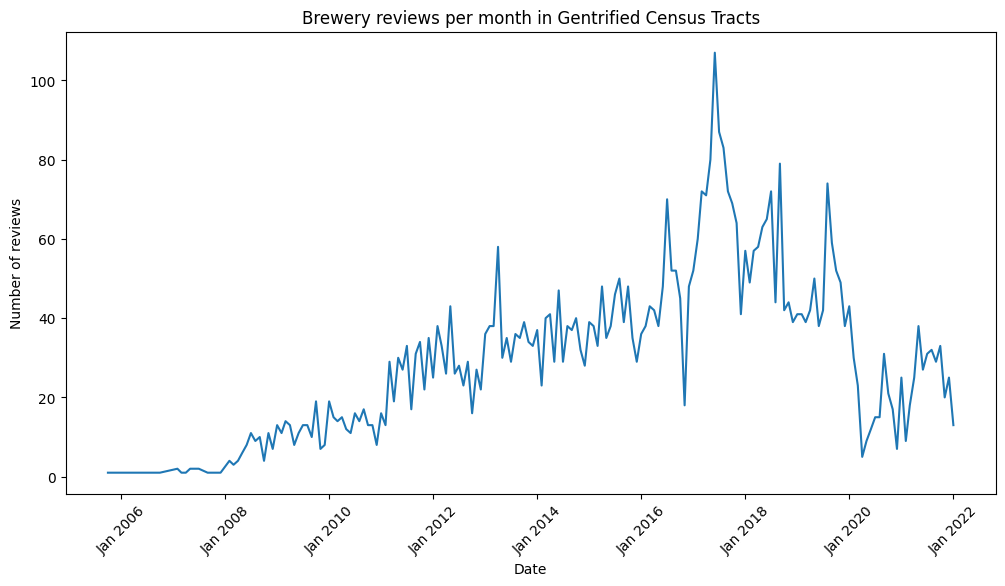

In [64]:
gentrified = reviews_tracts[reviews_tracts['GentYN'] == 1]

gent_review_counts = gentrified.groupby(gentrified['date'].dt.to_period('M')).size().reset_index(name='n')
gent_review_counts['date'] = gent_review_counts['date'].dt.to_timestamp()
gent_review_counts.set_index("date", inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(gent_review_counts['n'])
plt.xlabel("Date")
plt.ylabel("Number of reviews")
plt.title("Brewery reviews per month in Gentrified Census Tracts")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.show()

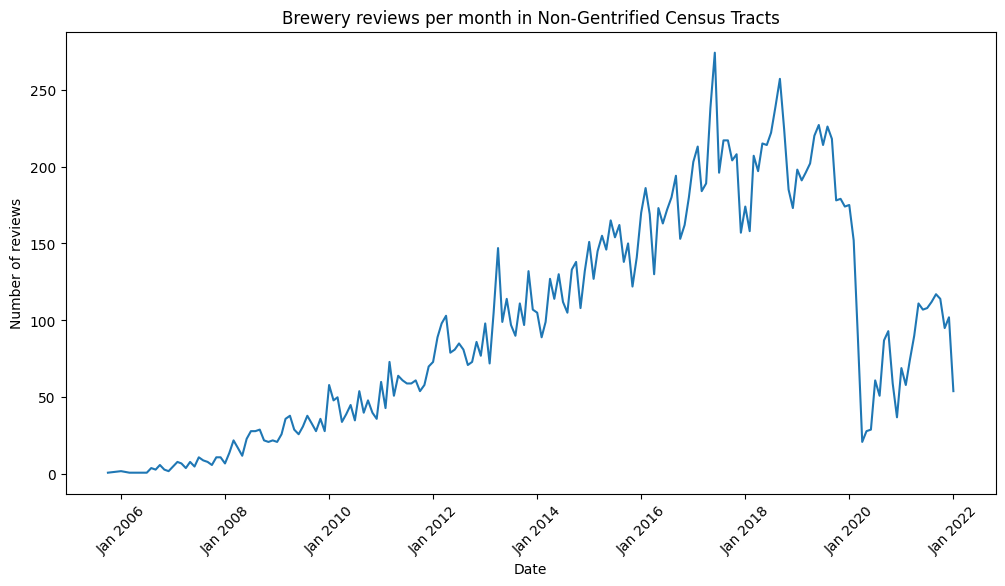

In [65]:
non_gentrified = reviews_tracts[reviews_tracts['gentrified'] == 0]

ng_review_counts = non_gentrified.groupby(non_gentrified['date'].dt.to_period('M')).size().reset_index(name='n')
ng_review_counts['date'] = ng_review_counts['date'].dt.to_timestamp()
ng_review_counts.set_index("date", inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(ng_review_counts['n'])
plt.xlabel("Date")
plt.ylabel("Number of reviews")
plt.title("Brewery reviews per month in Non-Gentrified Census Tracts")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.show()

## Restrict to pre-gentrification data time period (before 2010)

In [66]:
reviews_pre = reviews_tracts[reviews_tracts['date'] < '01-01-2010']
reviews_pre.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,useful,funny,cool,text,date,geometry,index_right,GentYN,TRACTCE10,GEOID10
32662,4_W5pstoN1166TGjjPOrMg,Prohibition Taproom,501 N 13th St,Philadelphia,PA,19123,39.961302,-75.159312,4.0,618,...,2.0,1.0,2.0,MMMMMMMM.\nThe place is slowly starting to get...,2009-05-26 03:01:17,POINT (-75.15931 39.9613),293.0,1.0,037600,42101037600
32669,4_W5pstoN1166TGjjPOrMg,Prohibition Taproom,501 N 13th St,Philadelphia,PA,19123,39.961302,-75.159312,4.0,618,...,2.0,0.0,2.0,I would have to say that I've visited Prohibit...,2009-05-19 17:33:41,POINT (-75.15931 39.9613),293.0,1.0,037600,42101037600
32671,4_W5pstoN1166TGjjPOrMg,Prohibition Taproom,501 N 13th St,Philadelphia,PA,19123,39.961302,-75.159312,4.0,618,...,3.0,2.0,2.0,"i live a block away from this place, yet took ...",2009-10-15 18:14:27,POINT (-75.15931 39.9613),293.0,1.0,037600,42101037600
32672,4_W5pstoN1166TGjjPOrMg,Prohibition Taproom,501 N 13th St,Philadelphia,PA,19123,39.961302,-75.159312,4.0,618,...,2.0,0.0,2.0,went on a saturday afternoon. the first ones t...,2009-05-20 02:25:55,POINT (-75.15931 39.9613),293.0,1.0,037600,42101037600
32674,4_W5pstoN1166TGjjPOrMg,Prohibition Taproom,501 N 13th St,Philadelphia,PA,19123,39.961302,-75.159312,4.0,618,...,3.0,1.0,2.0,I'm surprised at myself for only picking 3 sta...,2009-03-01 16:14:56,POINT (-75.15931 39.9613),293.0,1.0,037600,42101037600


In [ ]:
# check number of reviews in remaining data
reviews_pre.shape[0]

924

## Join with census track race/ethnicity data

In [70]:
race = pd.read_csv("data/race_ethn_cleaned_2010.csv")
race.head()

,Unnamed: 0,geography,geographic_area_name,tot_pop,TRACTCE,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only
0,0,1400000US42101000100,"Census Tract 1, Philadelphia County, Pennsylvania",3478,100.0,0.063830,0.125359,0.036228,0.774583
1,1,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937,200.0,0.102826,1.280899,0.026898,-0.410623
2,2,1400000US42101000300,"Census Tract 3, Philadelphia County, Pennsylvania",3169,300.0,0.107920,0.244241,0.042600,0.605238
3,3,1400000US42101000401,"Census Tract 4.01, Philadelphia County, Pennsy...",2125,401.0,0.186353,0.525176,0.050353,0.238118
4,4,1400000US42101000402,"Census Tract 4.02, Philadelphia County, Pennsy...",3142,402.0,0.056652,0.243794,0.034691,0.664863


In [68]:
reviews_pre.to_file("data/pre_2010_brew_reviews.gpkg")